In [15]:
from preprocess import preprocess_pipeline

mes_features = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g']

preprocess_full = preprocess_pipeline(
    file_path=r"..\data\en.openfoodfacts.org.products.csv.gz",
    chunksize=100_000,   # lit le csv 100 000 lignes à la fois au lieu de tout d'un coup
    missing_threshold=50,
    features=mes_features
)

print(preprocess_full["X_train"].shape)
preprocess_full["X_train"].head()

(758485, 7)


,energy_100g,saturated-fat_100g,sugars_100g,salt_100g,proteins_100g,fat_100g,carbohydrates_100g
716939,1855.6,5.1,27.2,0.8000,5.8,22.4,54.6
576959,272.0,0.0,16.0,0.0000,0.0,0.0,16.0
416885,1705.9,1.6,3.1,1.0825,12.0,5.9,74.0
1186649,2936.0,6.8,3.1,0.0100,14.3,68.1,5.1
260278,1024.7,7.7,6.1,1.4000,15.0,18.0,6.1


In [23]:
from outliers import apply_impossible_drop, identify_impossible

# on récupère X ET y
X_train = preprocess_full["X_train"]
y_train = preprocess_full["y_train"]
X_test  = preprocess_full["X_test"]
y_test  = preprocess_full["y_test"]

# --- on REGARDE d'abord quelles lignes sont impossibles ---
lignes_impossibles, comptes = identify_impossible(X_train)

print("Nombre de valeurs impossibles par colonne :")
for col, n in comptes.items():
    print(f"  {col} : {n}")

print(f"\nLignes impossibles à supprimer : {lignes_impossibles.sum()}")
print("\nVoici ces lignes (les valeurs impossibles) :")
print(X_train[lignes_impossibles])

# --- puis on SUPPRIME ---
avant = len(X_train)
X_train, y_train = apply_impossible_drop(X_train, y_train)
print(f"\n{avant - len(X_train)} ligne(s) impossible(s) retirée(s)")
print("X_train :", X_train.shape, "| y_train :", len(y_train))

Nombre de valeurs impossibles par colonne :
  energy_100g : 391
  saturated-fat_100g : 70
  sugars_100g : 1985
  salt_100g : 319
  proteins_100g : 607
  fat_100g : 177
  carbohydrates_100g : 325

Lignes impossibles à supprimer : 2805

Voici ces lignes (les valeurs impossibles) :
         energy_100g  saturated-fat_100g   sugars_100g   salt_100g  \
1257444  1173.000000            3.100000  13228.603518    1.200000   
1273775   866.000000            4.700000  13228.603518    1.300000   
1366524  2677.700000            1.800000      1.400000    0.070000   
1138002  3404.000000           14.000000  13228.603518    0.000000   
274250   1175.762000            5.510514  13228.603518    0.003275   
...              ...                 ...           ...         ...   
790074   1175.762000            5.510514  13228.603518    0.003575   
1188575  1921.560000           13.300000      2.170000  110.000000   
13224    1461.904762           16.666667  13228.603518    2.503571   
218134   6800.000000

In [17]:
from outliers import inspect_outliers
inspect_outliers(X_train)


energy_100g : 6765 outliers selon Tukey
Bornes : [-1336.50 ; 3467.50]

saturated-fat_100g : 54213 outliers selon Tukey
Bornes : [-10.70 ; 18.62]

sugars_100g : 91159 outliers selon Tukey
Bornes : [-19.50 ; 34.10]

salt_100g : 39269 outliers selon Tukey
Bornes : [-1.75 ; 3.13]

proteins_100g : 17805 outliers selon Tukey
Bornes : [-13.40 ; 28.20]

fat_100g : 27913 outliers selon Tukey
Bornes : [-31.04 ; 55.19]

carbohydrates_100g : 0 outliers selon Tukey
Bornes : [-67.95 ; 120.77]


{'energy_100g': 6765,
 'saturated-fat_100g': 54213,
 'sugars_100g': 91159,
 'salt_100g': 39269,
 'proteins_100g': 17805,
 'fat_100g': 27913,
 'carbohydrates_100g': 0}

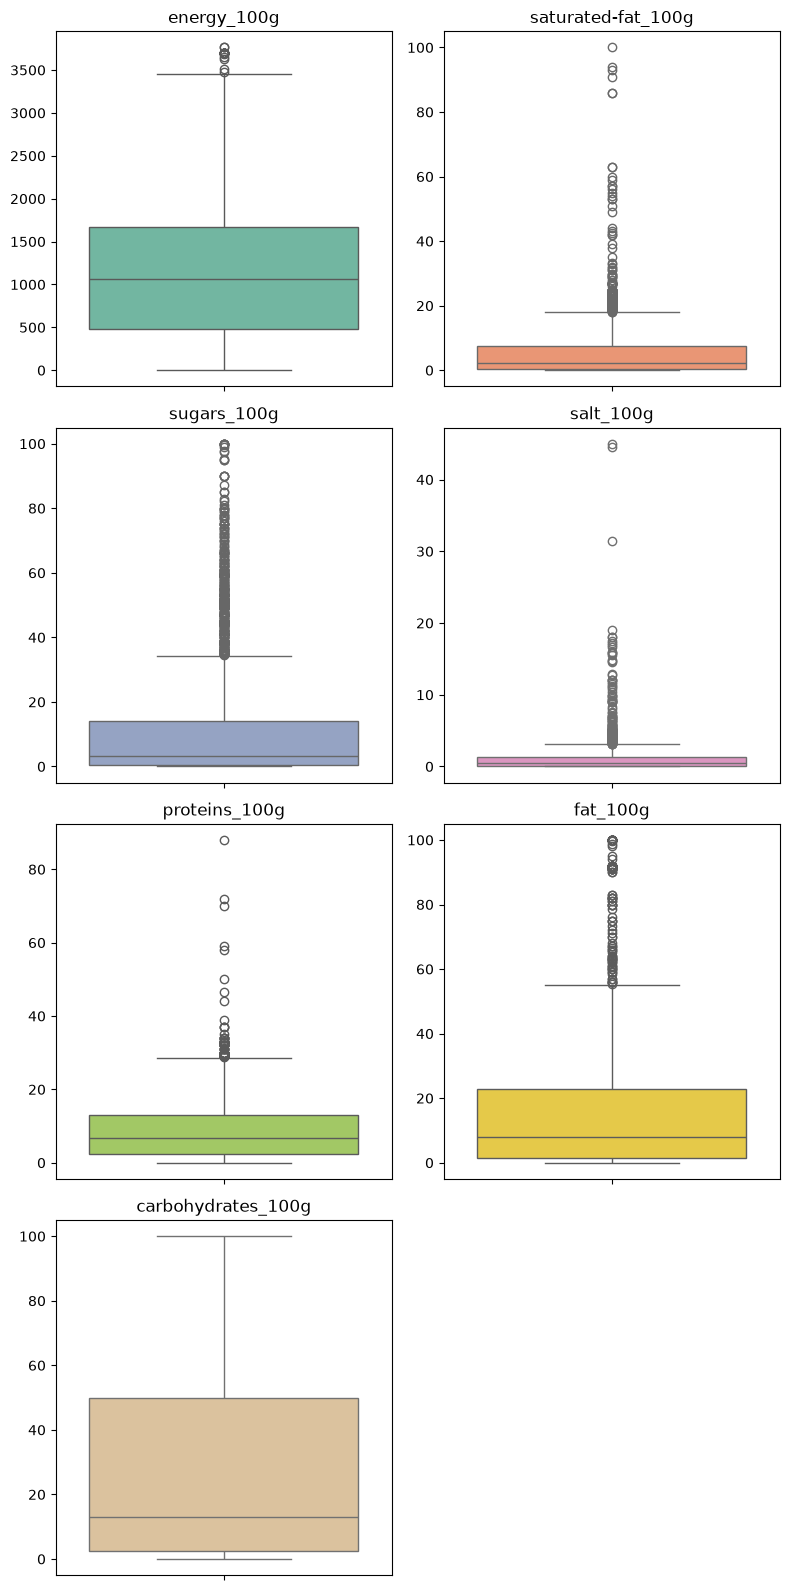

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['energy_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g',
        'proteins_100g', 'fat_100g', 'carbohydrates_100g']

# échantillon de 3000 lignes max pour les graphiques
X_graph = X_train.sample(3000, random_state=42) if len(X_train) > 3000 else X_train

# une couleur différente par colonne
couleurs = sns.color_palette("Set2", len(cols))

fig, axs = plt.subplots(4, 2, figsize=(8, 16))

for ax, col, couleur in zip(axs.flat, cols, couleurs):
    sns.boxplot(y=X_graph[col], ax=ax, color=couleur)
    ax.set_title(col)        # le nom est dans le titre
    ax.set_ylabel("")        # on enlève le nom sur l'axe y

axs.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

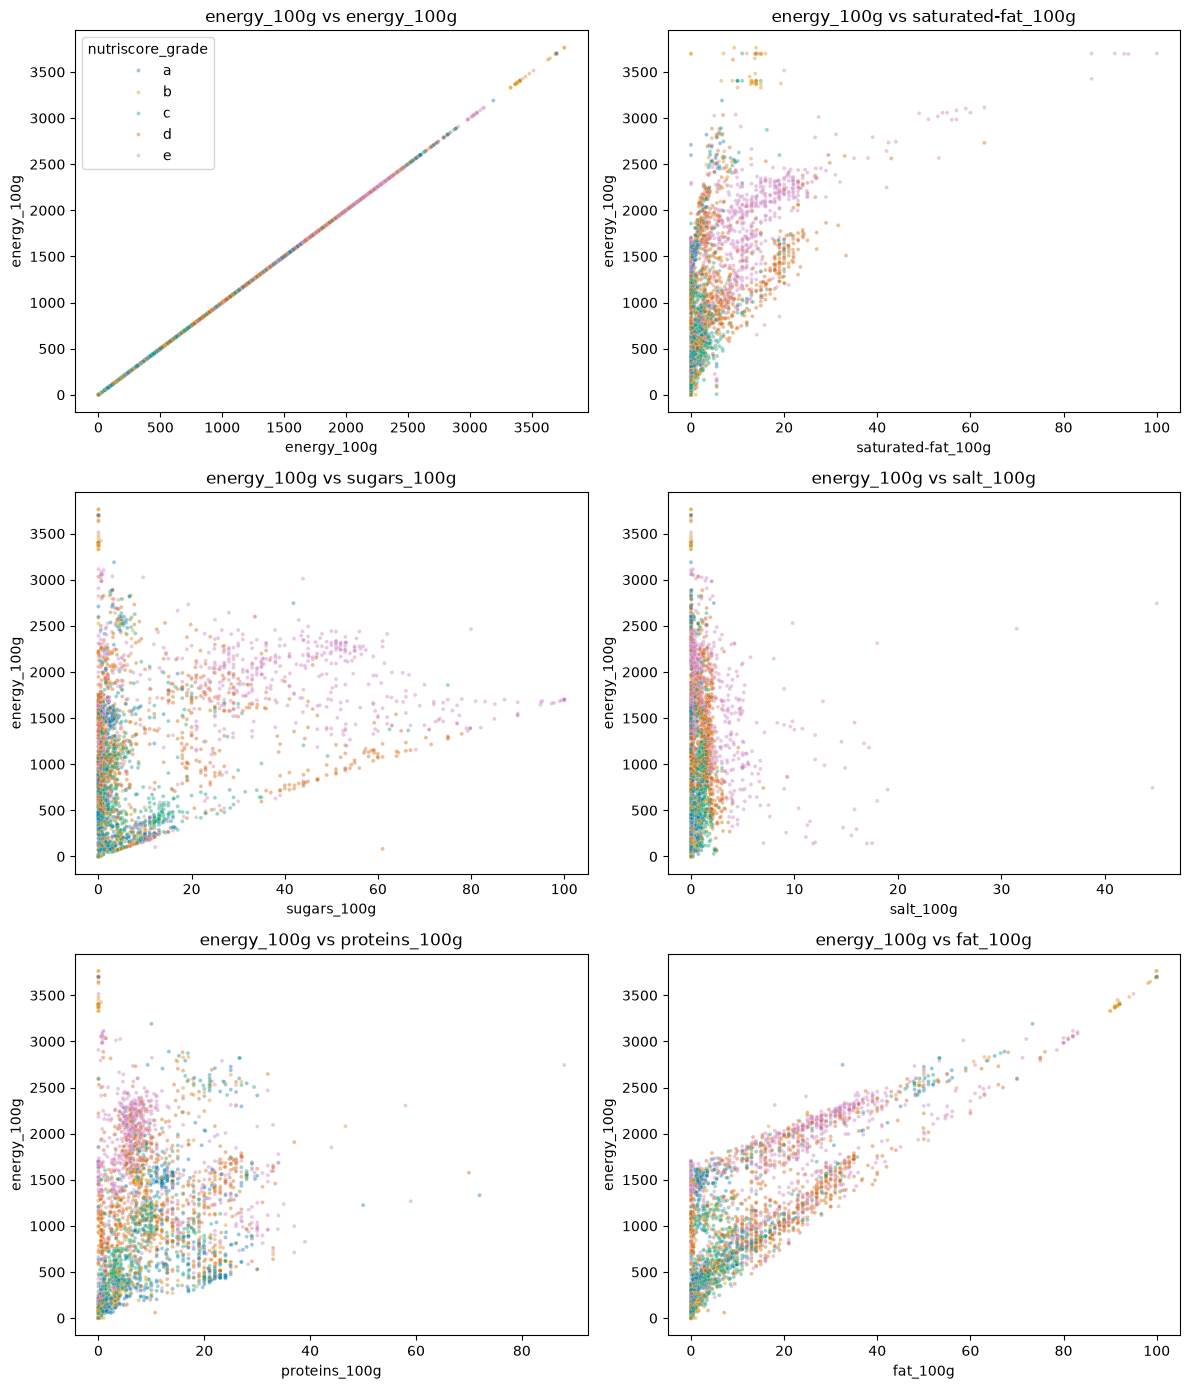

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# on recolle X et y temporairement
df_graph = X_train.copy()
df_graph["nutriscore_grade"] = y_train

# on prend un échantillon de 3000 points MAX pour le graphique (au lieu de tout)
if len(df_graph) > 3000:
    df_graph = df_graph.sample(3000, random_state=42)

fig, axs = plt.subplots(3, 2, figsize=(12, 14))

for ax, col in zip(axs.flat, cols):
    sns.scatterplot(data=df_graph, x=col, y="energy_100g",
                    hue="nutriscore_grade", hue_order=list("abcde"),
                    palette="colorblind", alpha=0.4, s=8,
                    ax=ax, legend=(ax is axs.flat[0]))
    ax.set_title(f"energy_100g vs {col}")

plt.tight_layout()
plt.show()